# 54 Modelo Híbrido 2 — Ensamble con componentes _def_2 optimizados

Versión mejorada del híbrido. Cada componente usa sus propias **features óptimas**
y sus propios **hiperparámetros** encontrados en los notebooks `_def_2` individuales.

| Componente | Notebook de referencia | Actualizar en config |
|---|---|---|
| Ridge | `51_linear_regression_def_2` | `RIDGE_FEATURES` |
| RF Regularizado | `52_random_forest_def_2` | `RF_FEATURES` · `RF_PARAMS` |
| XGBoost | `53_boost_def_2` | `XGB_FEATURES` · `XGB_PARAMS` |

**Cómo actualizar tras correr los _def_2 (Fase 2):**
1. Correr `51_def_2` → copiar `RIDGE_FEATURES_DEF['sale']` / `['rent']` en `RIDGE_FEATURES`
2. Correr `52_def_2` → copiar `RF_FEATURES_DEF` y `RF_PARAMS_DEF` en `RF_FEATURES` / `RF_PARAMS`
3. Correr `53_def_2` → copiar `XGB_FEATURES_DEF` y `XGB_PARAMS_DEF` en `XGB_FEATURES` / `XGB_PARAMS`
4. Re-ejecutar este notebook

**Por defecto:** se usa el superconjunto completo de features (mismo que `54_hibrido`) y los
parámetros actuales, para que el notebook sea funcional antes de completar la Fase 2.

In [61]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    HAS_XGB = False
    print("XGBoost no disponible — usando GradientBoostingRegressor como sustituto")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [62]:
# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS     = 5
TARGET_COL   = "log_precio"

# ── Features por componente y por dataset ─────────────────────────────────────
RIDGE_FEATURES = {
    "sale": ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'latitud_2', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'superficie_construida_m2_2', 'numero_banos_2', 'numero_dormitorios_2', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Noja', 'municipio_Ortuella', 'municipio_Piélagos', 'municipio_Polanco', 'municipio_Ribamontan al Mar', 'municipio_Ribamontan al Monte', 'municipio_Santa Cruz de Bezana', 'municipio_Santillana del Mar', 'municipio_Santoña', 'municipio_Santurtzi', 'municipio_Suances', 'municipio_Torrelavega', 'municipio_Villaescusa', 'municipio_Viveda', 'municipio_Voto', 'municipio_otro'],
    "rent": ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'tiene_ascensor_piso', 'tiene_garaje', 'precio_m2_municipio_media', 'latitud_2', 'score_cercania_servicios', 'numero_dormitorios_2', 'municipio_Laredo', 'municipio_Piélagos', 'municipio_Santander'],
}

RF_FEATURES = {
    "sale": ['superficie_construida_m2', 'numero_banos', 'precio_m2_municipio_media', 'tiene_ascensor_piso', 'latitud', 'ratio_banos_superficie', 'distancia_min_playa_km', 'tiene_garaje', 'longitud', 'ratio_dormitorios_superficie', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'distancia_min_colegio_km', 'numero_dormitorios', 'distancia_min_supermercado_km', 'tipologia_unificada_piso', 'planta_num', 'tipologia_unificada_unifamiliar', 'interaccion_planta_sin_ascensor_piso', 'es_exterior_piso'],
    "rent": ['superficie_construida_m2', 'precio_m2_municipio_media', 'numero_dormitorios', 'distancia_min_playa_km', 'numero_banos', 'latitud', 'longitud', 'score_cercania_servicios', 'ratio_banos_superficie', 'distancia_centro_municipio_km', 'ratio_dormitorios_superficie', 'distancia_min_colegio_km', 'distancia_min_supermercado_km', 'municipio_Laredo', 'planta_num', 'municipio_otro', 'tiene_garaje'],
}

XGB_FEATURES = {
    "sale": ['tiene_ascensor_piso', 'numero_banos', 'superficie_construida_m2', 'tiene_garaje', 'tipologia_unificada_piso', 'municipio_Santoña', 'precio_m2_municipio_media', 'numero_dormitorios', 'es_exterior_piso', 'interaccion_planta_sin_ascensor_piso', 'municipio_Castro-Urdiales', 'municipio_Ribamontan al Mar', 'municipio_Santander', 'municipio_El Astillero', 'municipio_Camargo', 'tipologia_unificada_unifamiliar', 'municipio_Torrelavega', 'latitud', 'ratio_banos_superficie', 'municipio_Barcena de Cicero', 'obra_nueva', 'distancia_min_playa_km', 'longitud', 'ratio_dormitorios_superficie', 'municipio_Suances', 'municipio_Laredo', 'score_cercania_servicios', 'municipio_Ampuero', 'municipio_Voto', 'distancia_centro_municipio_km', 'municipio_Santa Cruz de Bezana', 'planta_num', 'municipio_Mogro', 'municipio_Noja', 'distancia_min_colegio_km', 'distancia_min_supermercado_km', 'municipio_Piélagos'],
    "rent": ['numero_dormitorios', 'superficie_construida_m2', 'numero_banos', 'municipio_Laredo', 'precio_m2_municipio_media', 'municipio_Castro-Urdiales', 'distancia_min_playa_km', 'tipologia_unificada_unifamiliar', 'tipologia_unificada_piso', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'municipio_Santander', 'municipio_otro', 'tiene_ascensor_piso', 'municipio_Torrelavega', 'score_cercania_servicios', 'es_exterior_piso', 'latitud', 'tiene_garaje', 'longitud', 'distancia_centro_municipio_km', 'planta_num', 'interaccion_planta_sin_ascensor_piso', 'distancia_min_colegio_km', 'municipio_Piélagos', 'distancia_min_supermercado_km', 'municipio_Suances', 'municipio_Camargo', 'municipio_El Astillero'],
}

# ── Hiperparámetros Ridge ─────────────────────────────────────────────────────
# None → RidgeCV (búsqueda automática de alpha)
RIDGE_ALPHA = {
    "sale": 0.001000,
    "rent": None,
}

# ── Hiperparámetros RF ────────────────────────────────────────────────────────
RF_PARAMS = {
    "sale": dict(
        n_estimators=600, max_depth=23, min_samples_leaf=2,
        max_features=0.7011650633133736, ccp_alpha=1.575346560376712e-05,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "rent": dict(
        n_estimators=400, max_depth=15, min_samples_leaf=10,
        max_features=0.4, ccp_alpha=0.001,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

# ── Hiperparámetros XGBoost ───────────────────────────────────────────────────
XGB_PARAMS = {
    "sale": dict(
        n_estimators=600, max_depth=8, learning_rate=0.019653326029832427,
        subsample=0.7482390401967269, colsample_bytree=0.6337927911134054,
        min_child_weight=7, reg_lambda=0.6532280295230286, reg_alpha=0.03929462015394978,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
    "rent": dict(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_lambda=3,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
}

# ── Rutas de datos ────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv",
}
for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontró {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent_idealistaAPI.csv


In [63]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

_RIDGE_ALPHAS_DEFAULT = np.logspace(-3, 5, 200)

def build_X(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """Construye X para un componente específico.

    Si la lista de features ya incluye columnas municipio_* explícitas,
    usa solo esas. Si no incluye ninguna, añade todas las del gold dinámicamente.
    """
    df2 = df.copy()
    base_feats = [f for f in features if f in df2.columns]

    muni_in_features = [f for f in features if f.startswith("municipio_")]
    if not muni_in_features:
        # Sin municipios explícitos → añadir todos los del gold dinámicamente
        mun_cols  = sorted(c for c in df2.columns if c.startswith("municipio_"))
        all_feats = base_feats + [m for m in mun_cols if m not in base_feats]
    else:
        # Ya hay municipios explícitos → respetar la selección, no añadir más
        all_feats = base_feats

    X = df2[[f for f in all_feats if f in df2.columns]].copy()
    return X.fillna(X.median(numeric_only=True))


def create_models(ds_name: str) -> dict:
    alpha = RIDGE_ALPHA[ds_name]
    if alpha is not None:
        from sklearn.linear_model import Ridge
        ridge_mdl = Ridge(alpha=alpha)
    else:
        ridge_mdl = RidgeCV(alphas=_RIDGE_ALPHAS_DEFAULT, cv=N_SPLITS)

    ridge = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", StandardScaler()),
        ("mdl", ridge_mdl),
    ])
    rf = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("mdl", RandomForestRegressor(**RF_PARAMS[ds_name])),
    ])
    if HAS_XGB:
        boost_est = XGBRegressor(**XGB_PARAMS[ds_name])
    else:
        from sklearn.ensemble import GradientBoostingRegressor
        boost_est = GradientBoostingRegressor(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE,
        )
    boost = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("mdl", boost_est),
    ])
    return {"ridge": ridge, "rf_reg": rf, "boost": boost}


def compute_metrics(y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE":  float(mse),
        "RMSE": float(np.sqrt(mse)),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "MAPE": float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)),
    }


def get_cv_rmse(model, X, y) -> float:
    kf   = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pred = cross_val_predict(model, X, y, cv=kf)
    return float(np.sqrt(mean_squared_error(y, pred)))


def plot_diagnostics(y_test, pred_test, title: str) -> None:
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.4, s=18, color="steelblue")
    lim = [min(y_test.min(), pred_test.min()) - 0.05,
           max(y_test.max(), pred_test.max()) + 0.05]
    ax.plot(lim, lim, "r--", lw=1.5)
    ax.set(xlabel="Real (log_precio)", ylabel="Predicho (log_precio)",
           title="Real vs Predicho — test")

    ax = axes[1]
    ax.scatter(pred_test, residuals, alpha=0.4, s=18, color="darkorange")
    ax.axhline(0, color="red", ls="--", lw=1.5)
    ax.set(xlabel="Predicho", ylabel="Residuo", title="Residuos vs Predicho — test")

    ax = axes[2]
    ax.hist(residuals, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", ls="--", lw=1.5)
    ax.set(xlabel="Residuo", ylabel="Frecuencia", title="Distribución residuos")

    plt.tight_layout()
    plt.show()


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.



DATASET: SALE
Filas cargadas: 2694
Train: 2155 | Test: 539
Features por componente:
  ridge   : 50 features
  rf_reg  : 51 features
  boost   : 37 features

── Calibrando pesos por CV-RMSE ────────────────────────────────────
  ridge         CV-RMSE = 0.31495
  rf_reg        CV-RMSE = 0.27594
  boost         CV-RMSE = 0.26448
  Pesos finales: {'ridge': 0.3, 'rf_reg': 0.343, 'boost': 0.357}

── Métricas test — individuales y híbrido ──────────────────────────
 modelo     w n_feat     MSE    RMSE     MAE    MAPE      R2
  ridge 0.300     50 0.10682 0.32684 0.24712 0.01987 0.71905
 rf_reg 0.343     51 0.07573 0.27519 0.18875 0.01522 0.80082
  boost 0.357     37 0.06672 0.25830 0.17608 0.01418 0.82453
HÍBRIDO 1.000      — 0.07427 0.27252 0.19223 0.01548 0.80467

── Métricas híbrido — train vs test ────────────────────────────────
split     MSE    RMSE     MAE    MAPE      R2
train 0.02354 0.15343 0.11359 0.00909 0.92927
 test 0.07427 0.27252 0.19223 0.01548 0.80467

  delta RMSE test-trai

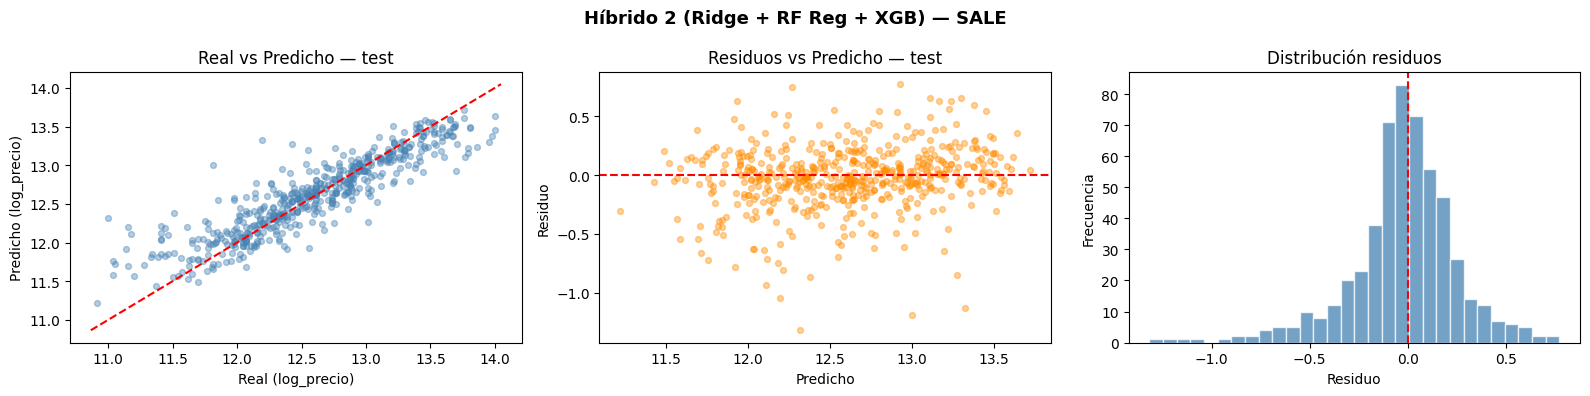


DATASET: RENT
Filas cargadas: 754
Train: 603 | Test: 151
Features por componente:
  ridge   : 12 features
  rf_reg  : 17 features
  boost   : 29 features

── Calibrando pesos por CV-RMSE ────────────────────────────────────
  ridge         CV-RMSE = 0.20162
  rf_reg        CV-RMSE = 0.21004
  boost         CV-RMSE = 0.21001
  Pesos finales: {'ridge': 0.342, 'rf_reg': 0.329, 'boost': 0.329}

── Métricas test — individuales y híbrido ──────────────────────────
 modelo     w n_feat     MSE    RMSE     MAE    MAPE      R2
  ridge 0.342     12 0.04648 0.21559 0.15766 0.02243 0.49044
 rf_reg 0.329     17 0.04899 0.22134 0.15677 0.02229 0.46292
  boost 0.329     29 0.05061 0.22498 0.15906 0.02266 0.44512
HÍBRIDO 1.000      — 0.04529 0.21281 0.15122 0.02150 0.50352

── Métricas híbrido — train vs test ────────────────────────────────
split     MSE    RMSE     MAE    MAPE      R2
train 0.02054 0.14332 0.10678 0.01542 0.74973
 test 0.04529 0.21281 0.15122 0.02150 0.50352

  delta RMSE test-trai

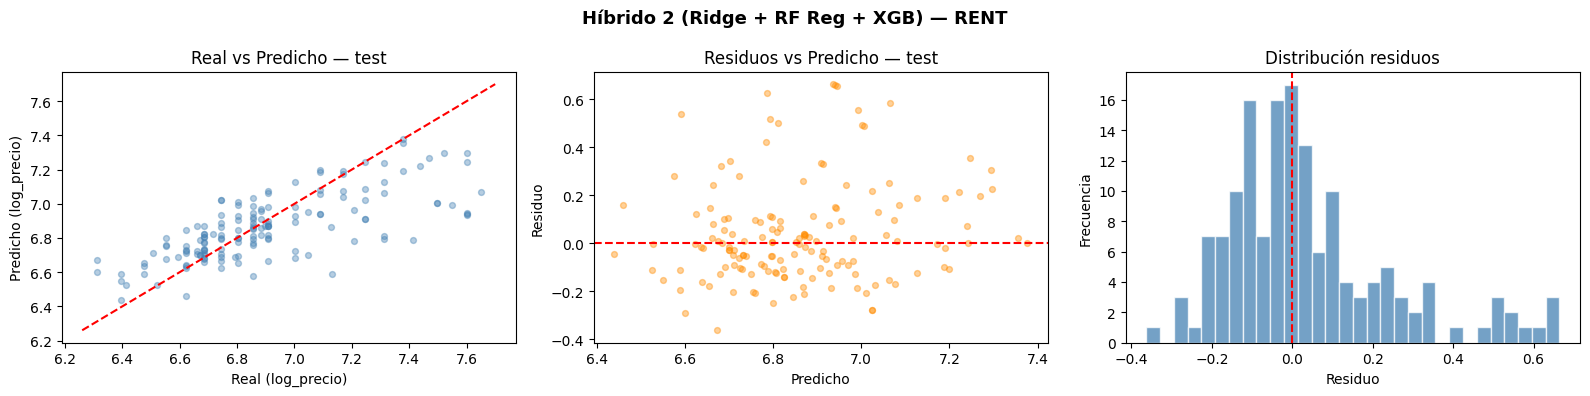

In [64]:
trained_state = {}
all_summary   = []

for ds_name, ds_path in DATASETS.items():
    print()
    print("=" * 90)
    print(f"DATASET: {ds_name.upper()}")
    print("=" * 90)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(ds_path)
    df = df[df[TARGET_COL].notna()].reset_index(drop=True)
    y  = df[TARGET_COL].copy()
    print(f"Filas cargadas: {len(df)}")

    # ── Split (mismas filas para todos los componentes) ───────────────────────
    train_idx, test_idx = train_test_split(
        np.arange(len(df)), test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test  = df.iloc[test_idx].reset_index(drop=True)
    y_train  = y.iloc[train_idx].reset_index(drop=True)
    y_test   = y.iloc[test_idx].reset_index(drop=True)
    print(f"Train: {len(df_train)} | Test: {len(df_test)}")

    # ── Matrices X por componente (features específicas del dataset) ──────────
    X_sets = {
        "ridge":  (build_X(df_train, RIDGE_FEATURES[ds_name]),
                   build_X(df_test,  RIDGE_FEATURES[ds_name])),
        "rf_reg": (build_X(df_train, RF_FEATURES[ds_name]),
                   build_X(df_test,  RF_FEATURES[ds_name])),
        "boost":  (build_X(df_train, XGB_FEATURES[ds_name]),
                   build_X(df_test,  XGB_FEATURES[ds_name])),
    }
    print("Features por componente:")
    for comp, (Xtr, Xte) in X_sets.items():
        print(f"  {comp:8s}: {Xtr.shape[1]} features")

    # ── Pesos automáticos basados en CV-RMSE ──────────────────────────────────
    print("\n── Calibrando pesos por CV-RMSE ────────────────────────────────────")
    models   = create_models(ds_name)
    cv_rmses = {}
    for name, model in models.items():
        X_tr, _ = X_sets[name]
        cv_rmses[name] = get_cv_rmse(model, X_tr, y_train)
        print(f"  {name:12s}  CV-RMSE = {cv_rmses[name]:.5f}")

    raw_w   = {k: 1.0 / v for k, v in cv_rmses.items()}
    total_w = sum(raw_w.values())
    weights = {k: v / total_w for k, v in raw_w.items()}
    print(f"  Pesos finales: { {k: round(v, 3) for k, v in weights.items()} }")

    # ── Entrenamiento final sobre train completo ───────────────────────────────
    for name, model in models.items():
        X_tr, _ = X_sets[name]
        model.fit(X_tr, y_train)

    # ── Predicciones híbridas ─────────────────────────────────────────────────
    pred_train = sum(weights[k] * models[k].predict(X_sets[k][0]) for k in models)
    pred_test  = sum(weights[k] * models[k].predict(X_sets[k][1]) for k in models)

    train_m = compute_metrics(y_train, pred_train)
    test_m  = compute_metrics(y_test,  pred_test)

    # ── Métricas individuales vs híbrido ─────────────────────────────────────
    print("\n── Métricas test — individuales y híbrido ──────────────────────────")
    rows = []
    for name, model in models.items():
        _, X_te = X_sets[name]
        m = compute_metrics(y_test, model.predict(X_te))
        rows.append({"modelo": name, "w": round(weights[name], 3),
                     "n_feat": X_sets[name][0].shape[1], **m})
    rows.append({"modelo": "HÍBRIDO", "w": 1.0, "n_feat": "—", **test_m})
    print(pd.DataFrame(rows).round(5).to_string(index=False))

    # ── Métricas train / test del híbrido ────────────────────────────────────
    print("\n── Métricas híbrido — train vs test ────────────────────────────────")
    print(pd.DataFrame([
        {"split": "train", **train_m},
        {"split": "test",  **test_m},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m['RMSE'] - train_m['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m['R2']  - test_m['R2']:+.5f}")

    plot_diagnostics(y_test, pred_test,
                     f"Híbrido 2 (Ridge + RF Reg + XGB) — {ds_name.upper()}")

    # ── Guardar estado ────────────────────────────────────────────────────────
    trained_state[ds_name] = {
        "models":   models,
        "weights":  weights,
        "X_sets":   X_sets,
        "df_raw":   df,
        "df_train": df_train,
        "df_test":  df_test,
    }

    all_summary.append({
        "dataset":    ds_name,
        "pesos":      str({k: round(v, 3) for k, v in weights.items()}),
        "train_RMSE": train_m["RMSE"], "train_R2": train_m["R2"],
        "test_RMSE":  test_m["RMSE"],  "test_R2":  test_m["R2"],
        "test_MAE":   test_m["MAE"],   "test_MAPE": test_m["MAPE"],
        "delta_RMSE": test_m["RMSE"] - train_m["RMSE"],
        "delta_R2":   train_m["R2"]  - test_m["R2"],
    })

In [65]:
print()
print("=" * 90)
print("RESUMEN GLOBAL — Modelo Híbrido 2")
print("=" * 90)
summary = pd.DataFrame(all_summary)
print(summary.round(5).to_string(index=False))
summary


RESUMEN GLOBAL — Modelo Híbrido 2
dataset                                             pesos  train_RMSE  train_R2  test_RMSE  test_R2  test_MAE  test_MAPE  delta_RMSE  delta_R2
   sale   {'ridge': 0.3, 'rf_reg': 0.343, 'boost': 0.357}     0.15343   0.92927    0.27252  0.80467   0.19223    0.01548     0.11910   0.12460
   rent {'ridge': 0.342, 'rf_reg': 0.329, 'boost': 0.329}     0.14332   0.74973    0.21281  0.50352   0.15122    0.02150     0.06949   0.24621


,dataset,pesos,train_RMSE,train_R2,test_RMSE,test_R2,test_MAE,test_MAPE,delta_RMSE,delta_R2
0,sale,"{'ridge': 0.3, 'rf_reg': 0.343, 'boost': 0.357}",0.153425,0.929272,0.272521,0.804670,0.192227,0.015484,0.119096,0.124602
1,rent,"{'ridge': 0.342, 'rf_reg': 0.329, 'boost': 0.329}",0.143316,0.749731,0.212808,0.503517,0.151219,0.021499,0.069492,0.246214


---
## Estimador de precio para una vivienda concreta

Rellena los parámetros de la celda siguiente y ejecútala para obtener:
- **Precio de venta estimado** (modelo entrenado sobre `final_sale_idealistaAPI.csv`)
- **Alquiler mensual estimado** (modelo entrenado sobre `final_rent_idealistaAPI.csv`)

In [66]:
# ── Tabla de referencia geográfica por municipio ──────────────────────────────
GEO_COLS = [
    "latitud", "longitud",
    "distancia_min_playa_km", "distancia_min_supermercado_km",
    "distancia_min_colegio_km", "precio_m2_municipio_media",
    "distancia_centro_municipio_km", "score_cercania_servicios",
]

municipio_ref = {}

for ds_name, state in trained_state.items():
    df_raw   = state["df_raw"]
    mun_cols = [c for c in df_raw.columns if c.startswith("municipio_")]

    rows = []
    for mc in mun_cols:
        nombre = mc.replace("municipio_", "")
        subset = df_raw[df_raw[mc] == 1]
        if len(subset) == 0:
            continue
        row = {"municipio": nombre}
        for gc in GEO_COLS:
            row[gc] = subset[gc].median() if gc in subset.columns else np.nan
        rows.append(row)

    municipio_ref[ds_name] = pd.DataFrame(rows).set_index("municipio")

print("Municipios disponibles (SALE):")
print(sorted(municipio_ref["sale"].index.tolist()))
print()
print("Municipios disponibles (RENT):")
print(sorted(municipio_ref["rent"].index.tolist()))

Municipios disponibles (SALE):
['Ampuero', 'Barcena de Cicero', 'Camargo', 'Castro-Urdiales', 'Colindres', 'Cudon', 'El Astillero', 'Guarnizo', 'Laredo', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Miengo', 'Mogro', 'Noja', 'Ortuella', 'Piélagos', 'Polanco', 'Ribamontan al Mar', 'Ribamontan al Monte', 'Santa Cruz de Bezana', 'Santander', 'Santillana del Mar', 'Santoña', 'Santurtzi', 'Suances', 'Torrelavega', 'Villaescusa', 'Viveda', 'Voto', 'otro']

Municipios disponibles (RENT):
['Camargo', 'Castro-Urdiales', 'El Astillero', 'Laredo', 'Piélagos', 'Santa Cruz de Bezana', 'Santander', 'Suances', 'Torrelavega', 'otro']


In [67]:
# ══════════════════════════════════════════════════════════════════════════════
#  ESTIMADOR DE PRECIO — modifica los valores y ejecuta la celda
# ══════════════════════════════════════════════════════════════════════════════

MUNICIPIO      = "Santa Cruz de Bezana"
SUPERFICIE_M2  = 90
N_DORMITORIOS  = 3
N_BANOS        = 2
TIENE_GARAJE   = True
OBRA_NUEVA     = False
TIPOLOGIA      = "piso"       # "piso"  o  "unifamiliar"

# Solo para PISO (pon None si es unifamiliar)
PLANTA         = 2
ES_EXTERIOR    = True
TIENE_ASCENSOR = True


def _build_row(municipio, sup, dorm, banos, planta, exterior,
               ascensor, garaje, obra_nueva, tipologia, feature_cols, geo_stats):
    """Construye la fila de features para una vivienda dado un conjunto de feature_cols."""
    row = pd.Series(np.nan, index=feature_cols)

    def _set(k, v):
        if k in row.index and v is not None:
            row[k] = v

    _set("superficie_construida_m2",       sup)
    _set("numero_dormitorios",             dorm)
    _set("numero_banos",                   banos)
    _set("tiene_garaje",                   int(garaje))
    _set("obra_nueva",                     int(obra_nueva))
    _set("tipologia_unificada_piso",       1 if tipologia == "piso"        else 0)
    _set("tipologia_unificada_unifamiliar", 1 if tipologia == "unifamiliar" else 0)
    _set("planta_num",                     planta)
    _set("es_exterior_piso",    int(exterior) if exterior is not None else None)
    _set("tiene_ascensor_piso", int(ascensor) if ascensor is not None else None)

    if tipologia == "piso" and planta is not None and ascensor is not None:
        _set("interaccion_planta_sin_ascensor_piso", planta * (1 - int(ascensor)))
    else:
        _set("interaccion_planta_sin_ascensor_piso", 0)

    _set("ratio_dormitorios_superficie", dorm / sup if sup > 0 else 0)
    _set("ratio_banos_superficie",       banos / sup if sup > 0 else 0)

    for col, val in geo_stats.items():
        _set(col, val)

    mun_cols_feat = [c for c in feature_cols if c.startswith("municipio_")]
    for c in mun_cols_feat:
        row[c] = 0.0
    mun_col = f"municipio_{municipio}"
    if mun_col in row.index:
        row[mun_col] = 1.0
    elif "municipio_otro" in row.index:
        row["municipio_otro"] = 1.0

    return pd.DataFrame([row])


def estimar_precio(municipio, sup, dorm, banos, planta, exterior,
                   ascensor, garaje, obra_nueva, tipologia):
    desc = []
    if tipologia == "piso":
        if planta   is not None: desc.append(f"Planta {planta}")
        if exterior is not None: desc.append("exterior" if exterior else "interior")
        if ascensor is not None: desc.append("con ascensor" if ascensor else "sin ascensor")
    if garaje:     desc.append("garaje")
    if obra_nueva: desc.append("obra nueva")

    print()
    print("=" * 62)
    print(f"  VIVIENDA  {sup} m²  ·  {dorm} dorm.  ·  {banos} baños  —  {municipio}")
    print(f"  {tipologia.upper()}  ·  {' · '.join(desc) if desc else '—'}")
    print("=" * 62)

    for ds_name, state in trained_state.items():
        ref = municipio_ref.get(ds_name)
        if ref is None or municipio not in ref.index:
            disponibles = sorted(ref.index.tolist()) if ref is not None else []
            print(f"\n  [{ds_name.upper()}] Municipio '{municipio}' no encontrado.")
            print(f"  Disponibles: {disponibles}")
            continue

        geo_stats = ref.loc[municipio].to_dict()
        models    = state["models"]
        weights   = state["weights"]

        # Predicción por componente usando sus propias features
        log_pred = 0.0
        for comp_name in models:
            feat_cols = list(state["X_sets"][comp_name][0].columns)
            X_pred    = _build_row(municipio, sup, dorm, banos, planta, exterior,
                                   ascensor, garaje, obra_nueva, tipologia,
                                   feat_cols, geo_stats)
            log_pred += weights[comp_name] * models[comp_name].predict(X_pred)[0]

        precio = np.exp(log_pred)
        if ds_name == "sale":
            print(f"  Precio de venta estimado   : {precio:>12,.0f} €")
        else:
            print(f"  Alquiler mensual estimado  : {precio:>12,.0f} €/mes")
    print()


estimar_precio(
    MUNICIPIO, SUPERFICIE_M2, N_DORMITORIOS, N_BANOS,
    PLANTA, ES_EXTERIOR, TIENE_ASCENSOR, TIENE_GARAJE, OBRA_NUEVA, TIPOLOGIA
)


  VIVIENDA  90 m²  ·  3 dorm.  ·  2 baños  —  Santa Cruz de Bezana
  PISO  ·  Planta 2 · exterior · con ascensor · garaje
  Precio de venta estimado   :       21,612 €
  Alquiler mensual estimado  :          996 €/mes

